# Model Spikey observed by *Kepler* with JAXNS

In this notebook we use the Bayesian inference package [`JAXNS`](https://github.com/Joshuaalbert/jaxns), using nested sampling, to model the Kepler observation of Spikey, reduced by Smith+2016. 

In [10]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Built-in
import os
import sys
import json
import copy
import datetime
import warnings

# Dependencies
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist

# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [12]:
# Hide warnings
warnings.filterwarnings("ignore")

In [13]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
cm = 'orange'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 1. *Kepler* light curve with 1-d cadence
---

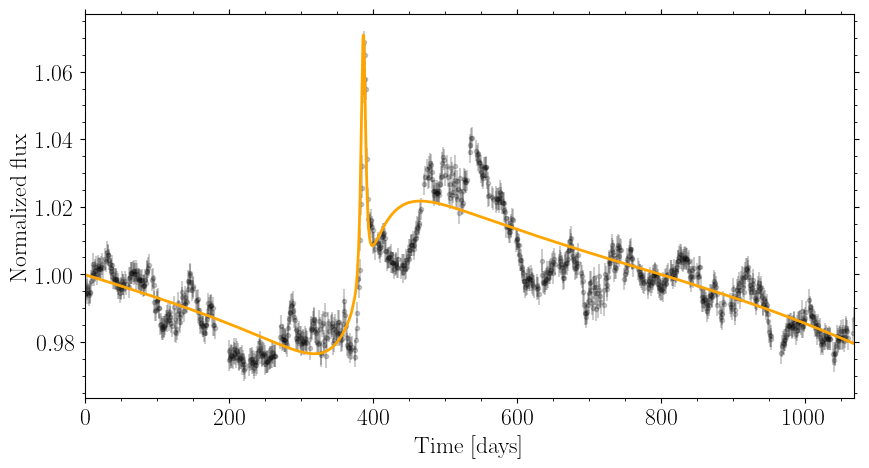

In [15]:
# Load Kepler light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_kepler_smith2016.ftr')
Q0 = 12

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0
model = smbhb.model(params)
dm = model.light_curve(df.time.to_numpy(), df=True)

# Create a 1-d binned light curve and plot
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Load default model priors
priors_DM  = bs.model_priors(params, model='DM') 
priors_Q   = bs.model_priors(params, model='Q',   flux=flux) 
priors_QDM = bs.model_priors(params, model='QDM', flux=flux) 

# Plot light curve
fig, ax = pt.plot_lc(df, dm, cm=cm);

---
### 1.1 Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 8217750
samples: 32064
phantom samples: 0
likelihood evals / sample: 256.3
phantom fraction (%): 0.0%
--------
logZ=3825.933 +- 0.068
max(logL)=3833.655
H=-6.28
ESS=3139
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.9956 +- 0.0093 | 0.9849 / 0.9958 / 1.0064 | 0.996 | 0.996
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0178 +- 0.0042 | 0.0135 / 0.0169 / 0.0233 | 0.015 | 0.015
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 148.0 +- 79.0 | 79.0 / 126.0 / 242.0 | 99.0 | 99.0
--------
CPU times: user 1h 38min 30s, sys: 3min 53s, total: 1h 42min 24s
Wall time: 29min 39s
```

In [6]:
filename = rdir / 'spikey_kepler_jaxns_3yr24h_Q.npy'

In [148]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_Q, 
#     build_mean=None, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [9]:
result = ut.load_result(filename)

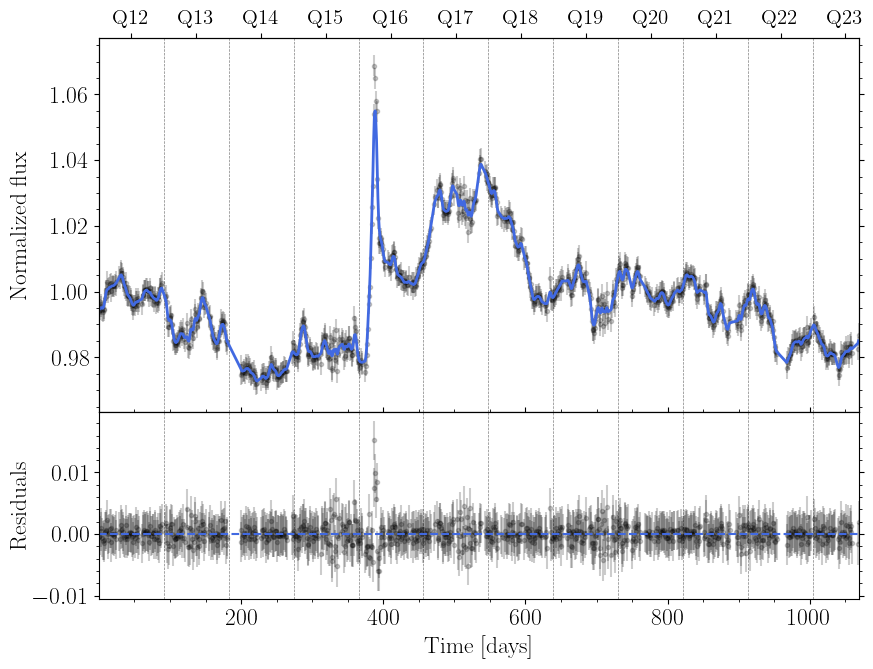

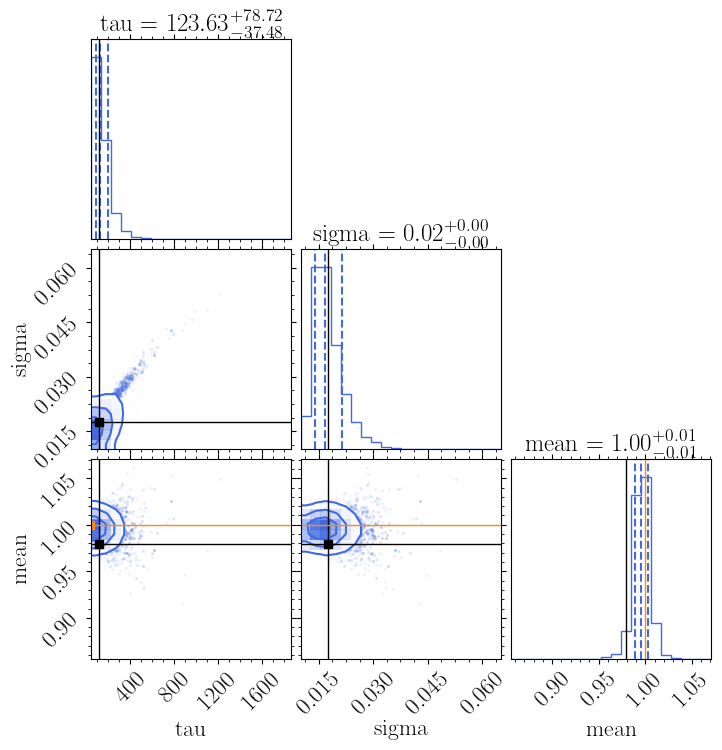

In [18]:
dm = bs.model_lightcurve_drw(time, result)
fig, ax = pt.plot_result(df, dm,  Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [20]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

tau : pmx { 123.63324 }{ -37.48121 }{ 78.71903 }
sigma : pmx { 0.01678 }{ -0.00269 }{ 0.00463 }
mean : pmx { 0.99592 }{ -0.00744 }{ 0.00742 }


---
### 1.2. Model DM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 77470256
samples: 89178
phantom samples: 0
likelihood evals / sample: 868.7
phantom fraction (%): 0.0%
--------
logZ=2286.36 +- 0.17
max(logL)=2332.16
H=-40.97
ESS=5231
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.447 +- 0.053 | 0.376 / 0.442 / 0.509 | 0.434 | 0.434
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.1302 +- 0.0039 | 1.1251 / 1.1303 / 1.1352 | 1.1307 | 1.1307
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: -0.35 +- 0.3 | -0.83 / -0.29 / -0.0 | -0.48 | -0.48
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.4178 +- 0.0064 | 0.4094 / 0.4179 / 0.4258 | 0.4162 | 0.4162
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 85.08 +- 0.22 | 84.78 / 85.09 / 85.38 | 85.16 | 85.16
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 7.225 +- 0.091 | 7.155 / 7.228 / 7.314 | 7.225 | 7.225
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.712 +- 0.089 | 6.616 / 6.708 / 6.801 | 6.697 | 6.697
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.0424 +- 0.0013 | 1.0408 / 1.0424 / 1.0441 | 1.042 | 1.042
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 83.0 +- 19.0 | 80.0 / 81.0 / 81.0 | 81.0 | 81.0
--------
CPU times: user 10h 7min 1s, sys: 4min 39s, total: 10h 11min 41s
Wall time: 1h 38min 9s
```

In [21]:
filename = rdir / 'spikey_kepler_jaxns_3yr24h_DM.npy'

In [249]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_DM, 
#     build_mean=bs.smbhb_mean_builder,
#     build_kernel=None, 
#     ofile=filename
# )

In [22]:
result = ut.load_result(filename)

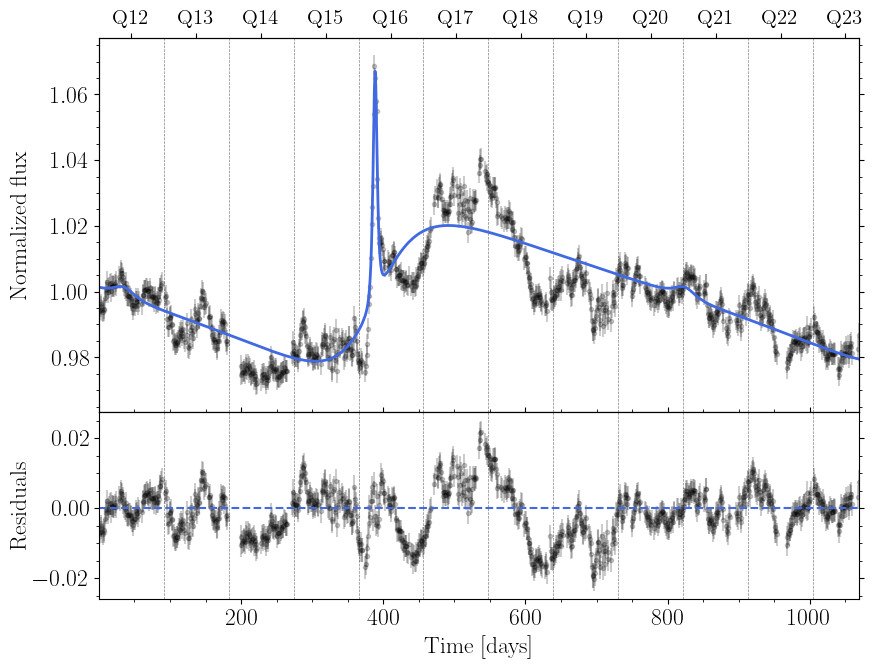

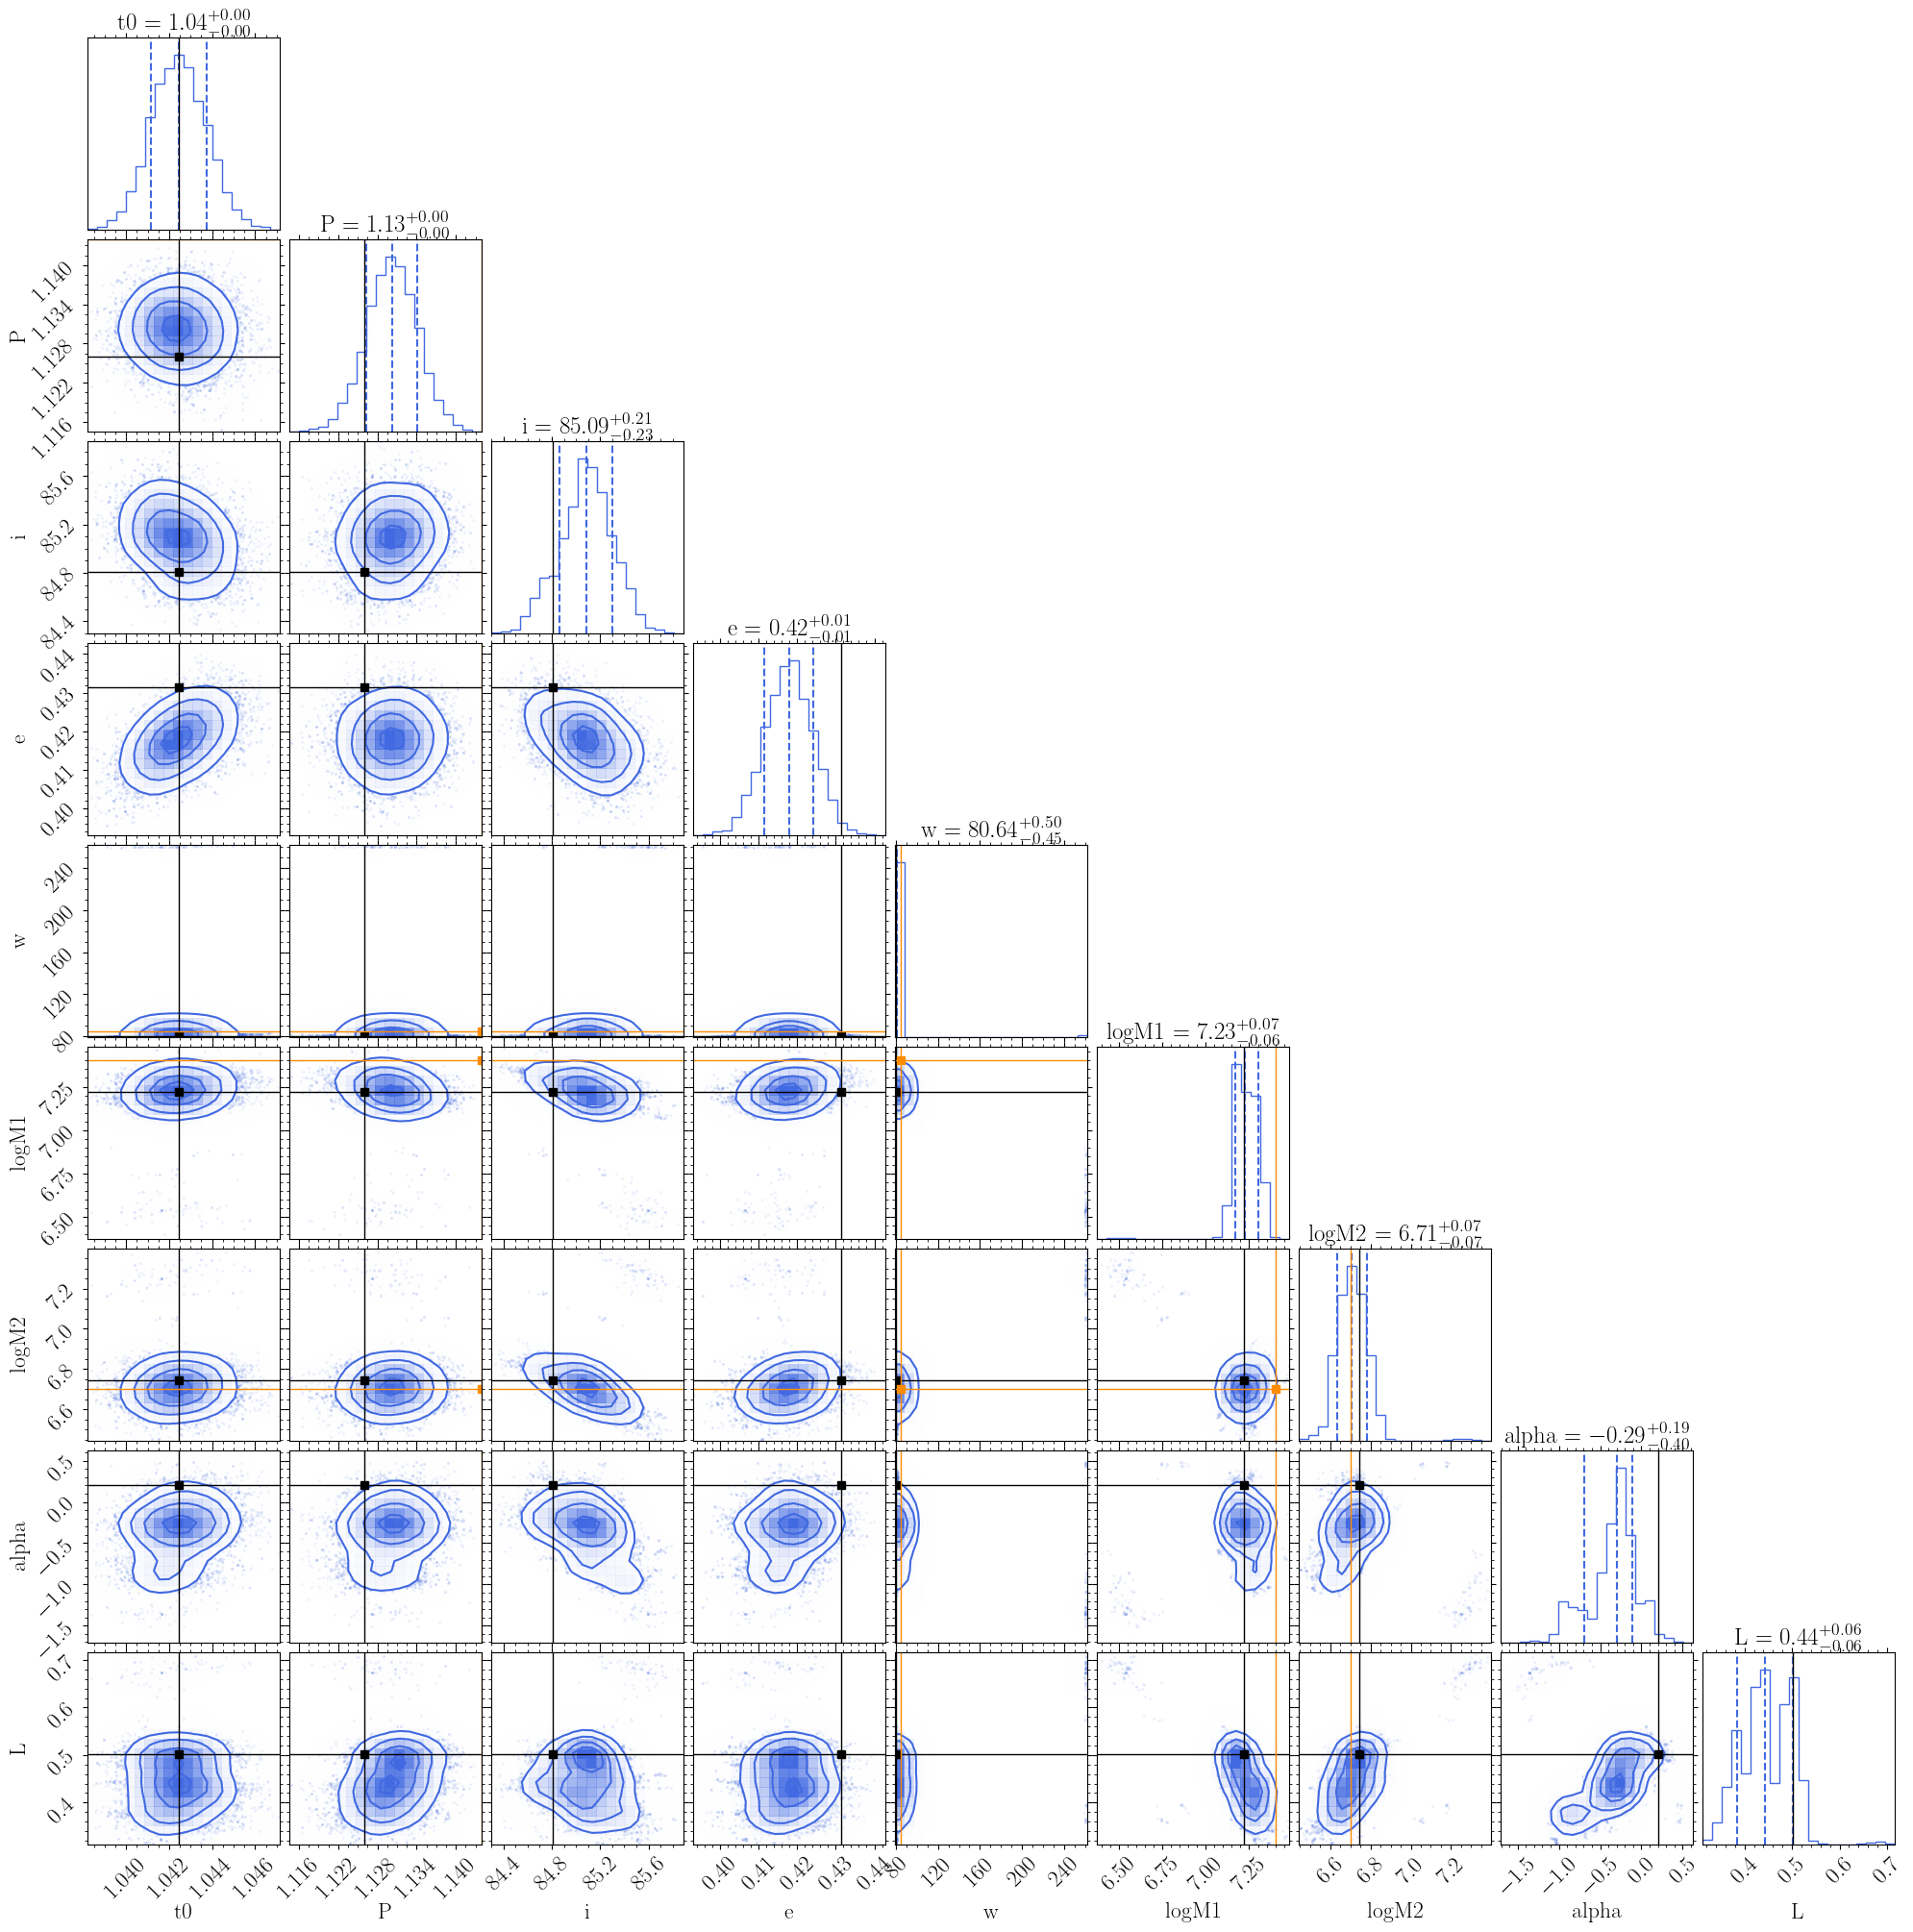

In [23]:
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

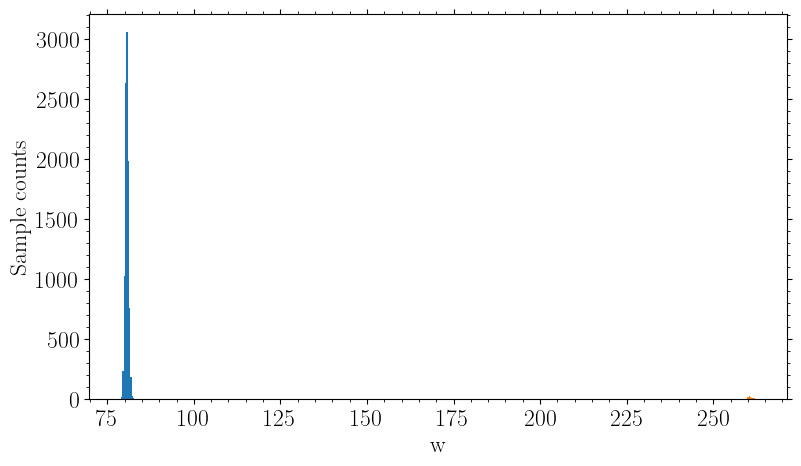

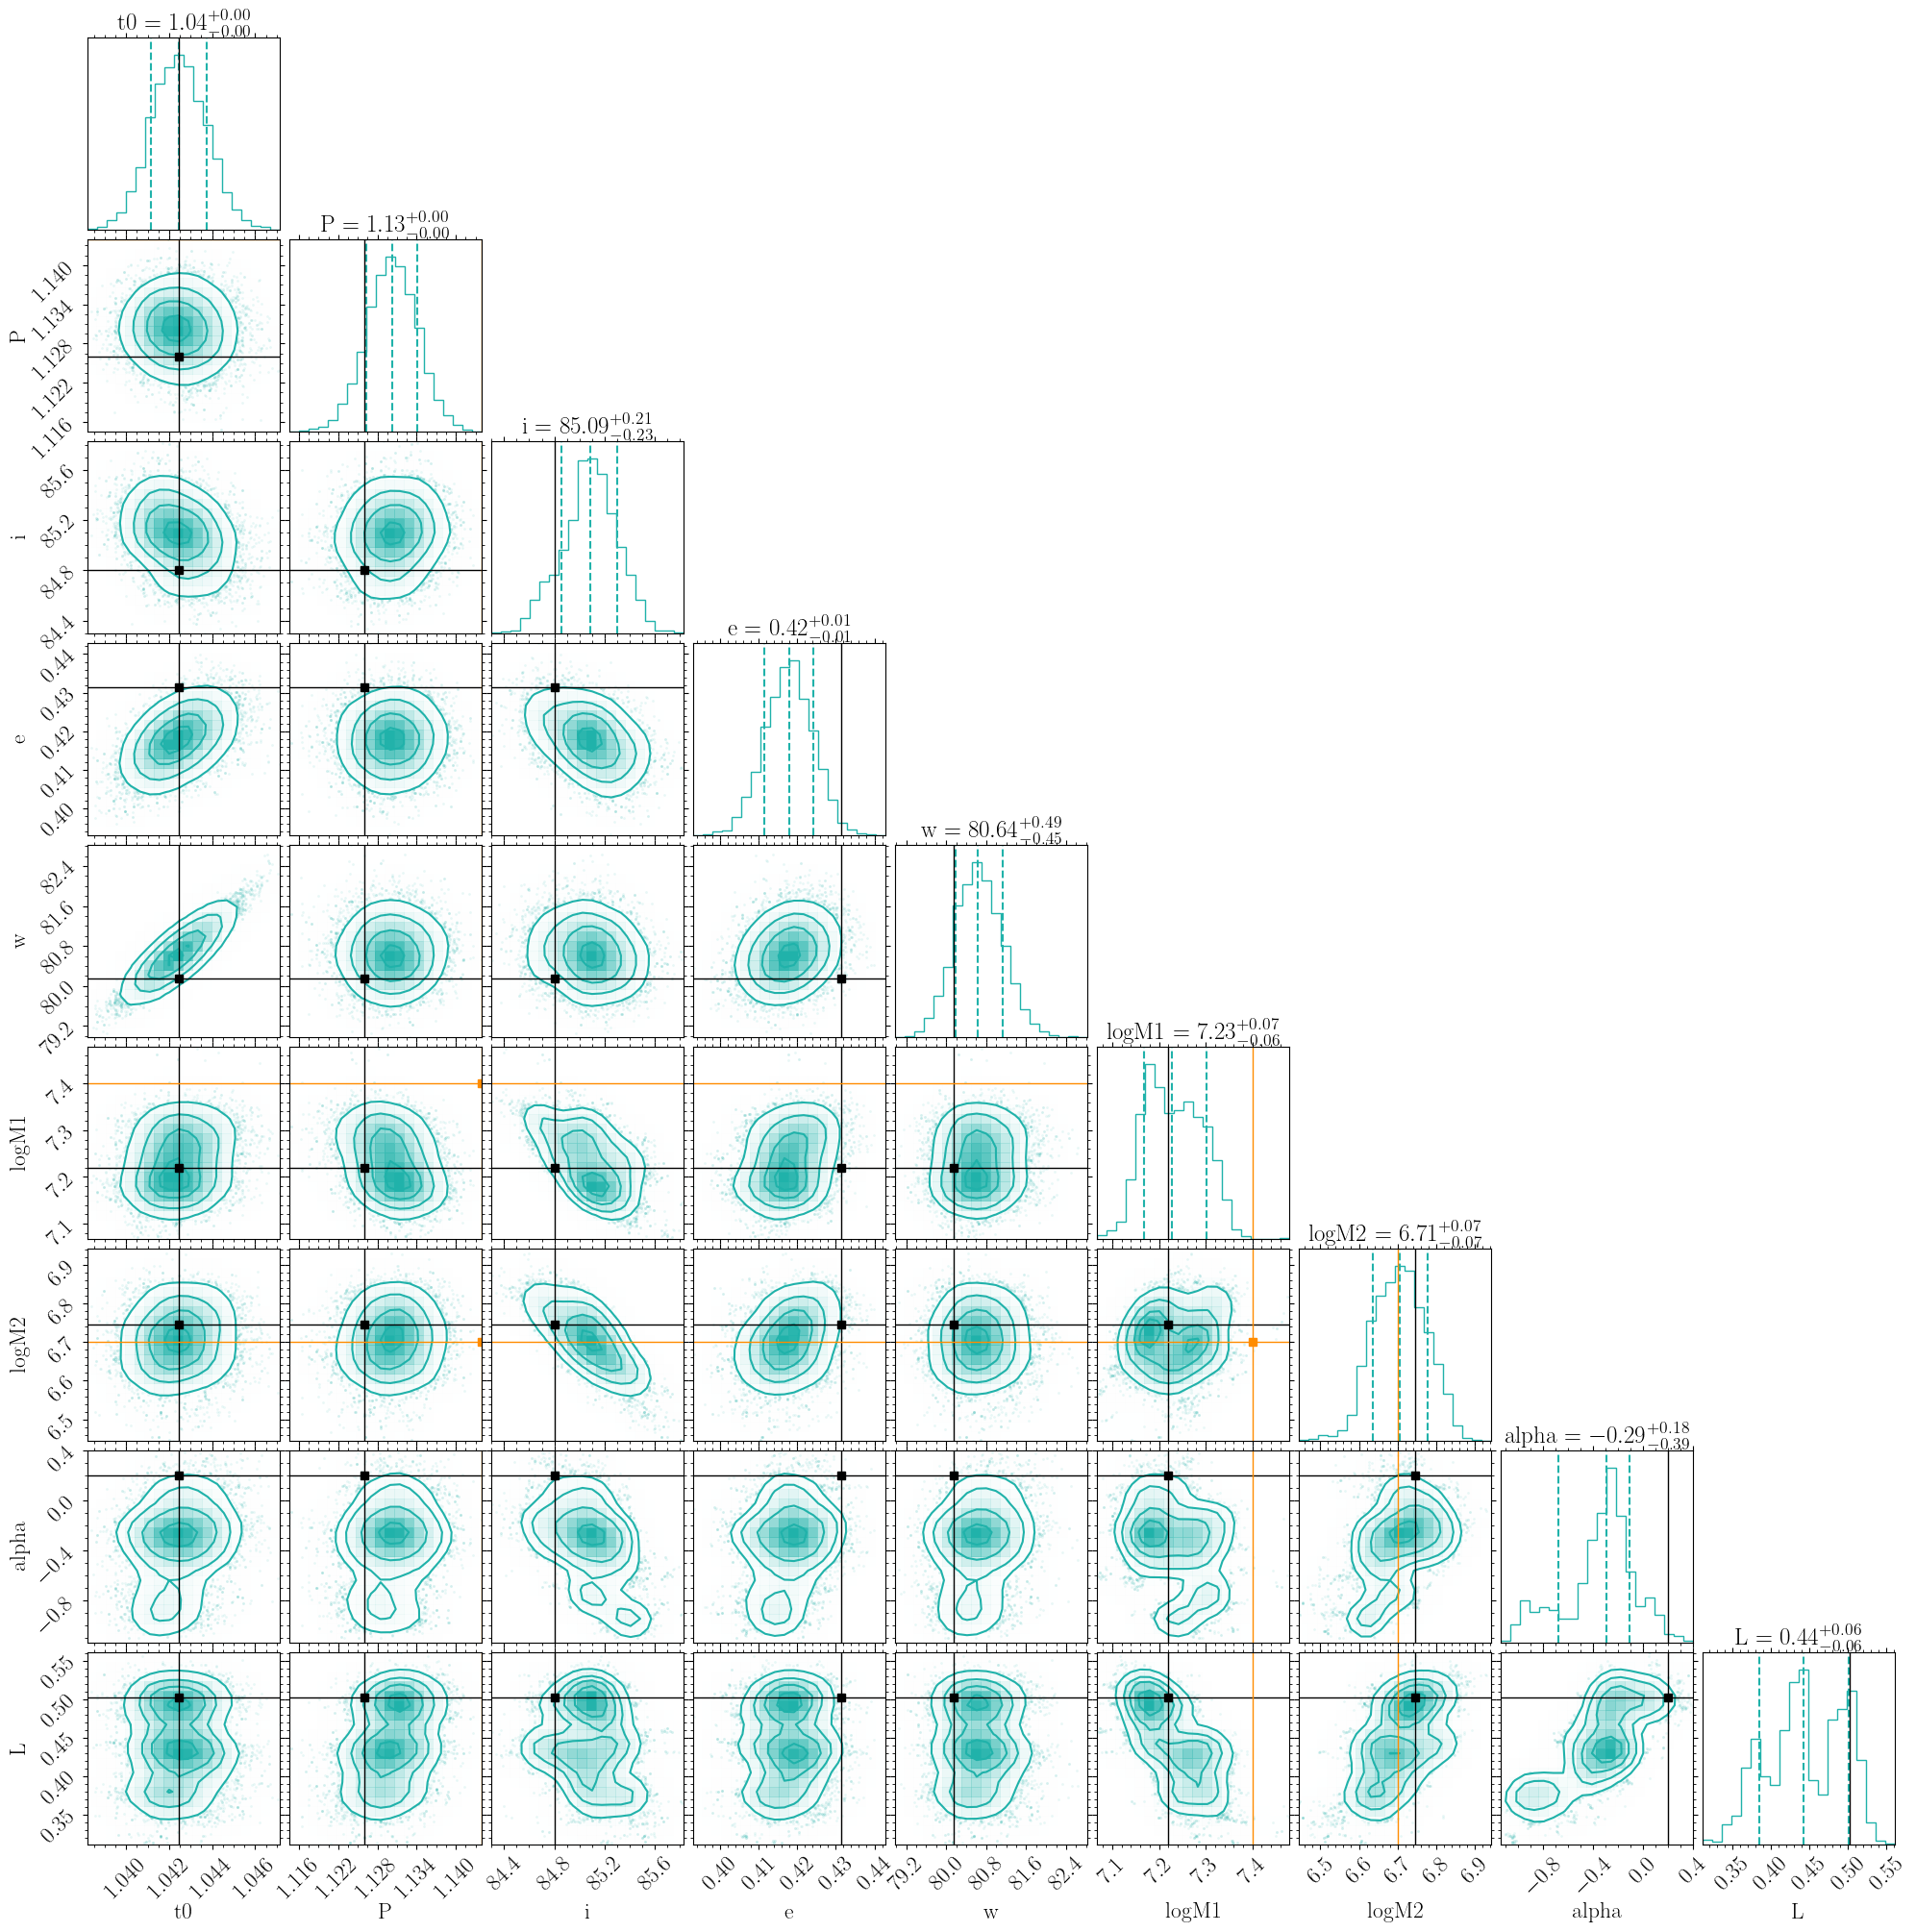

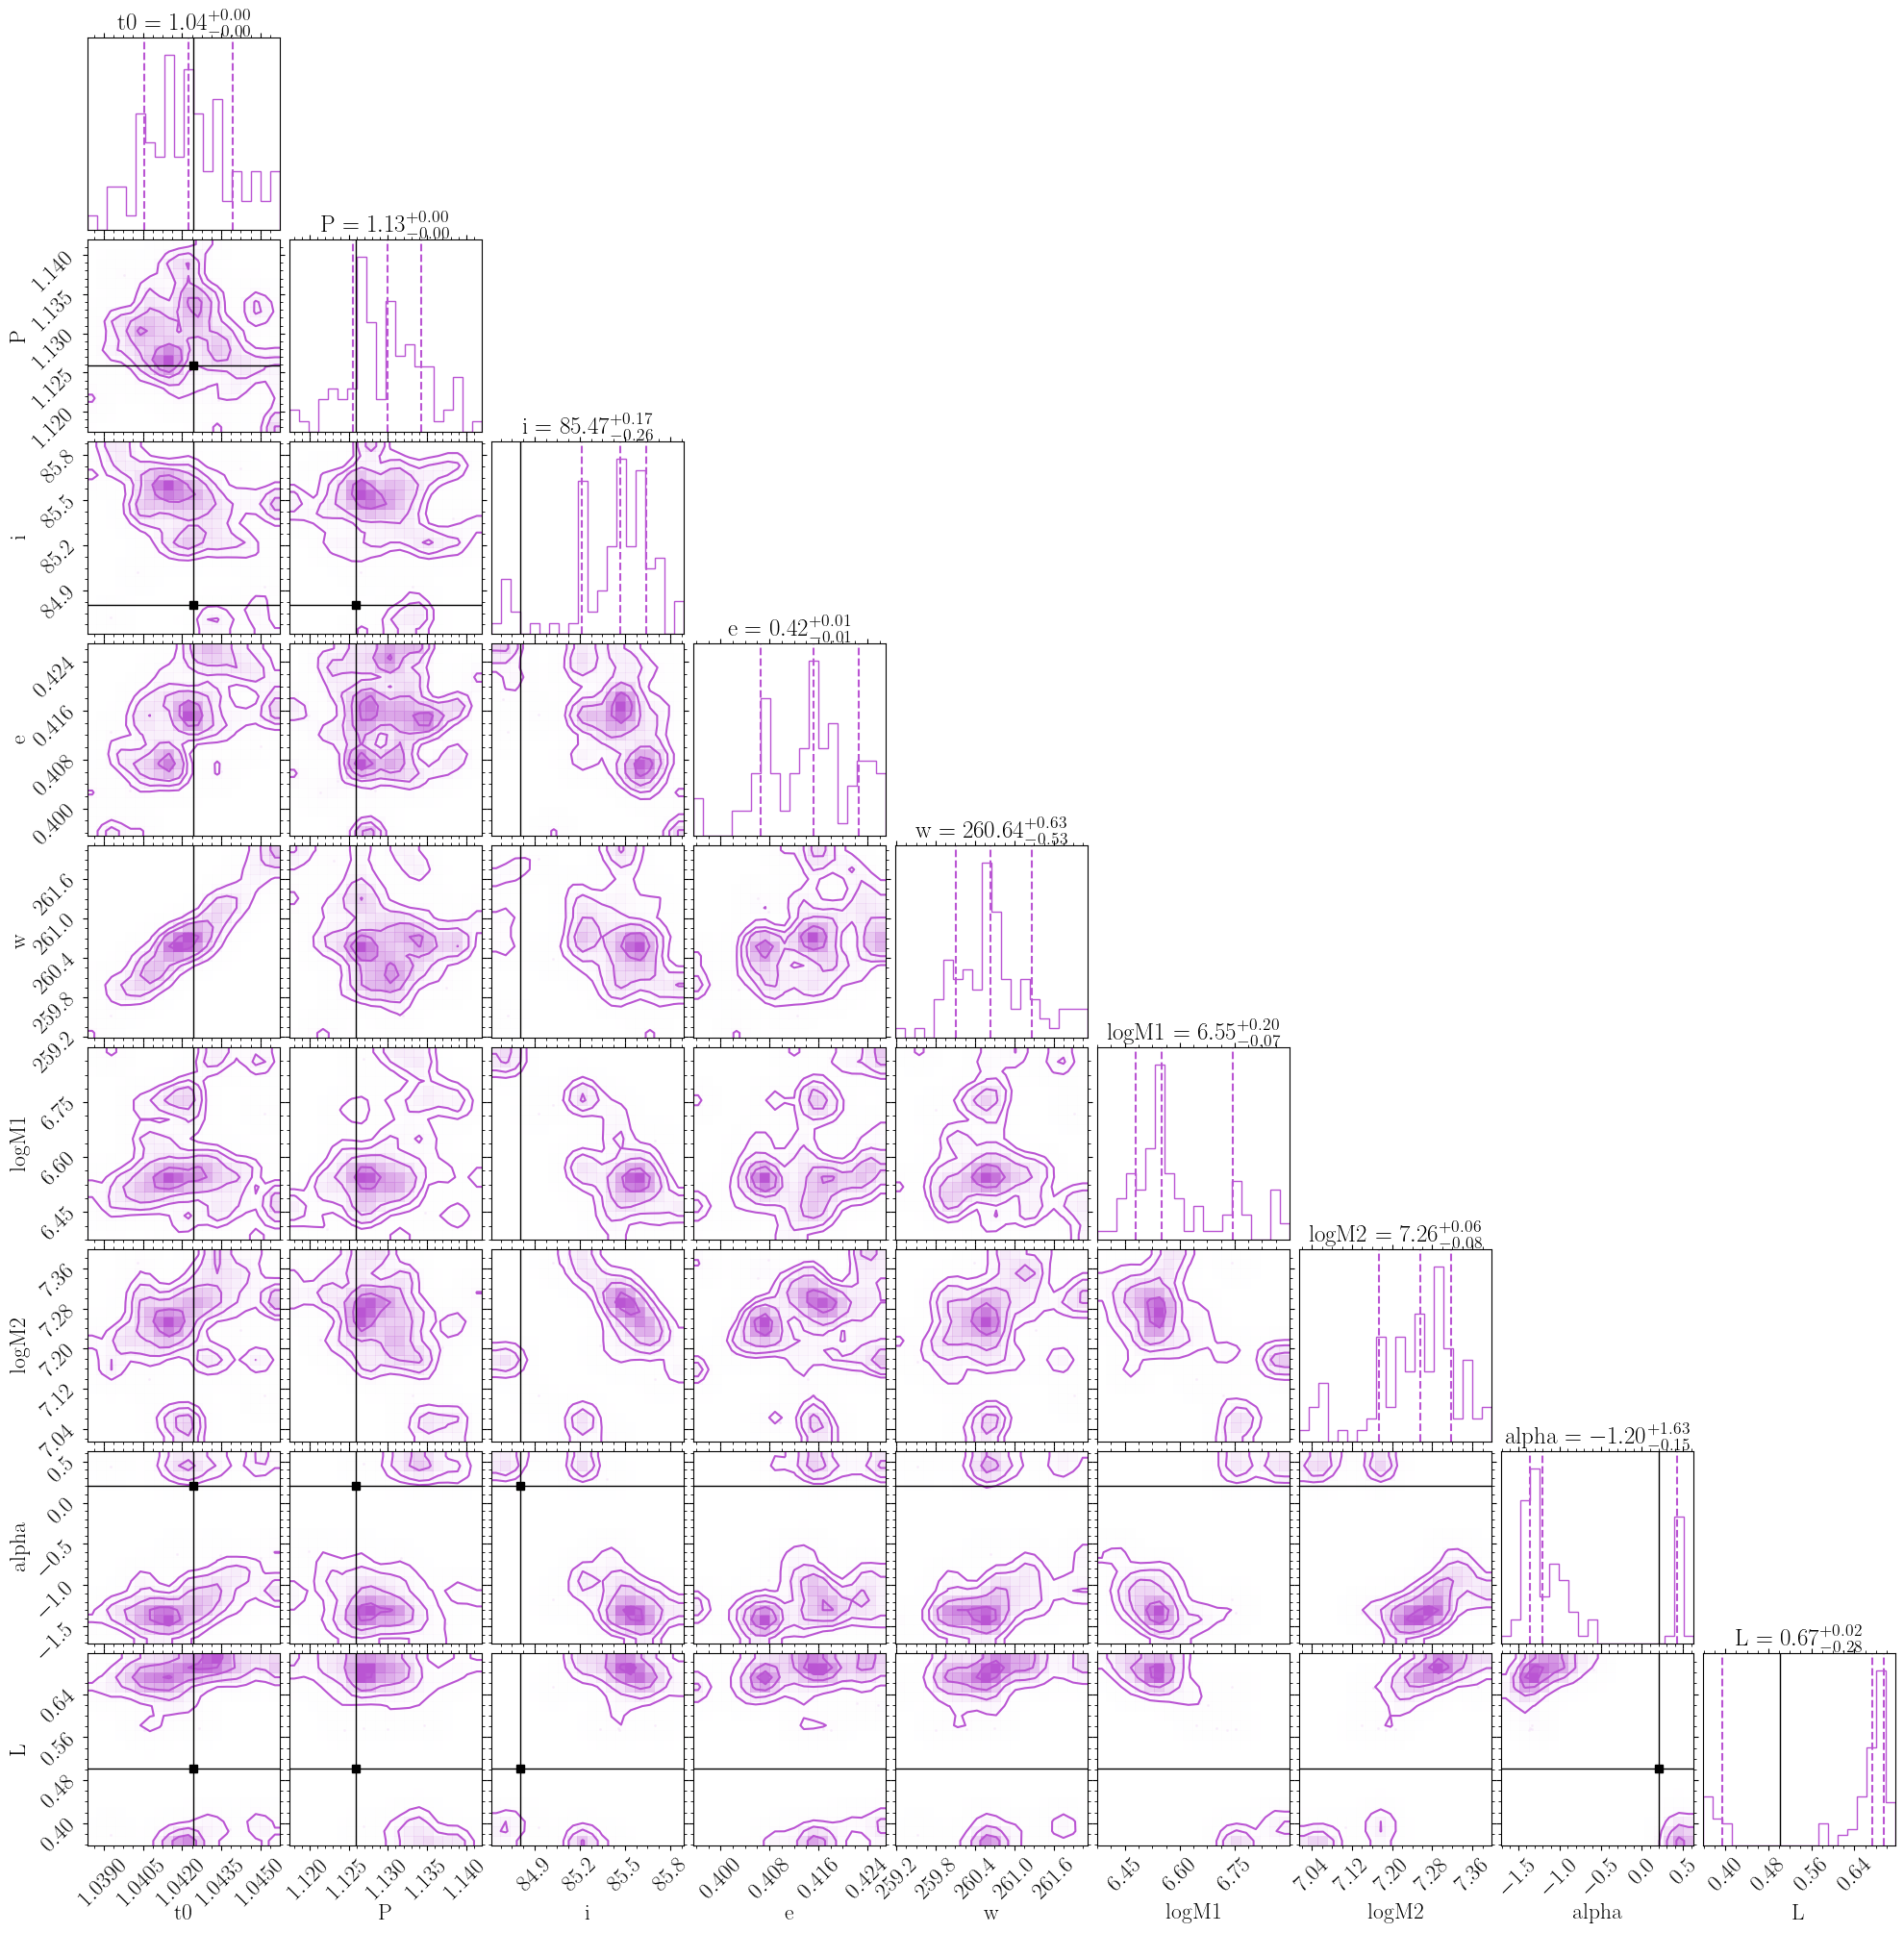

In [24]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

In [25]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

t0 : pmx { 1.04243 }{ -0.00127 }{ 0.00132 }
P : pmx { 1.13026 }{ -0.00388 }{ 0.00378 }
i : pmx { 85.08792 }{ -0.22835 }{ 0.20883 }
e : pmx { 0.41788 }{ -0.00630 }{ 0.00621 }
w : pmx { 80.63936 }{ -0.45198 }{ 0.49152 }
logM1 : pmx { 7.22818 }{ -0.05933 }{ 0.07278 }
logM2 : pmx { 6.70651 }{ -0.07107 }{ 0.07248 }
alpha : pmx { -0.29170 }{ -0.38646 }{ 0.18410 }
L : pmx { 0.44198 }{ -0.05661 }{ 0.05888 }


---
### 1.3. Model QDM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 66478191
samples: 66132
phantom samples: 0
likelihood evals / sample: 1005.2
phantom fraction (%): 0.0%
--------
logZ=3957.78 +- 0.13
max(logL)=3987.64
H=-23.11
ESS=7093
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.71 +- 0.21 | 0.39 / 0.73 / 0.92 | 0.98 | 0.98
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 2.9 +- 1.0 | 1.3 / 3.1 / 4.1 | 1.7 | 1.7
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 2.37 +- 0.87 | 1.84 / 2.58 / 2.79 | 2.83 | 2.83
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.867 +- 0.097 | 0.738 / 0.909 / 0.938 | 0.899 | 0.899
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 60.0 +- 16.0 | 38.0 / 62.0 / 79.0 | 32.0 | 32.0
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 7.4 +- 1.1 | 5.9 / 7.4 / 8.8 | 9.3 | 9.3
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 8.7 +- 1.3 | 6.5 / 9.1 / 9.8 | 6.2 | 6.2
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0121 +- 0.0021 | 0.0099 / 0.012 / 0.0146 | 0.0113 | 0.0113
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.065 +- 0.022 | 1.044 / 1.069 / 1.075 | 1.07 | 1.07
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 190.0 +- 76.0 | 132.0 / 170.0 / 269.0 | 162.0 | 162.0
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 254.0 +- 78.0 | 110.0 / 286.0 / 319.0 | 135.0 | 135.0
--------
CPU times: user 14h 9min 16s, sys: 45min 35s, total: 14h 54min 52s
Wall time: 4h 1min 47s
```

In [26]:
filename = rdir / 'spikey_kepler_jaxns_3yr24h_QDM.npy'

In [157]:
# %%time 
# result = bs.run_jaxns(
#     df, params, priors_QDM, 
#     build_mean=bs.smbhb_mean_builder, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [27]:
result = ut.load_result(filename)

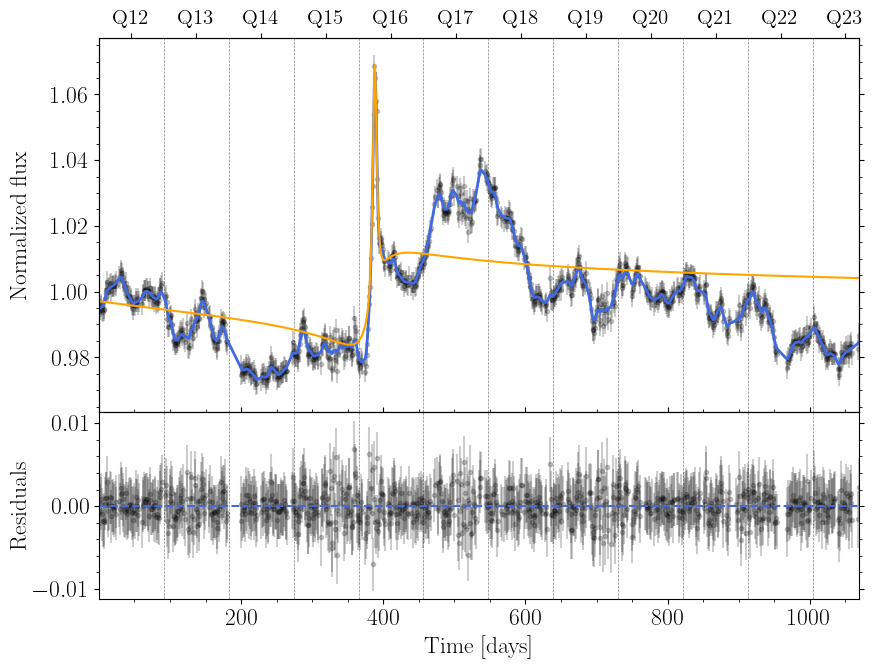

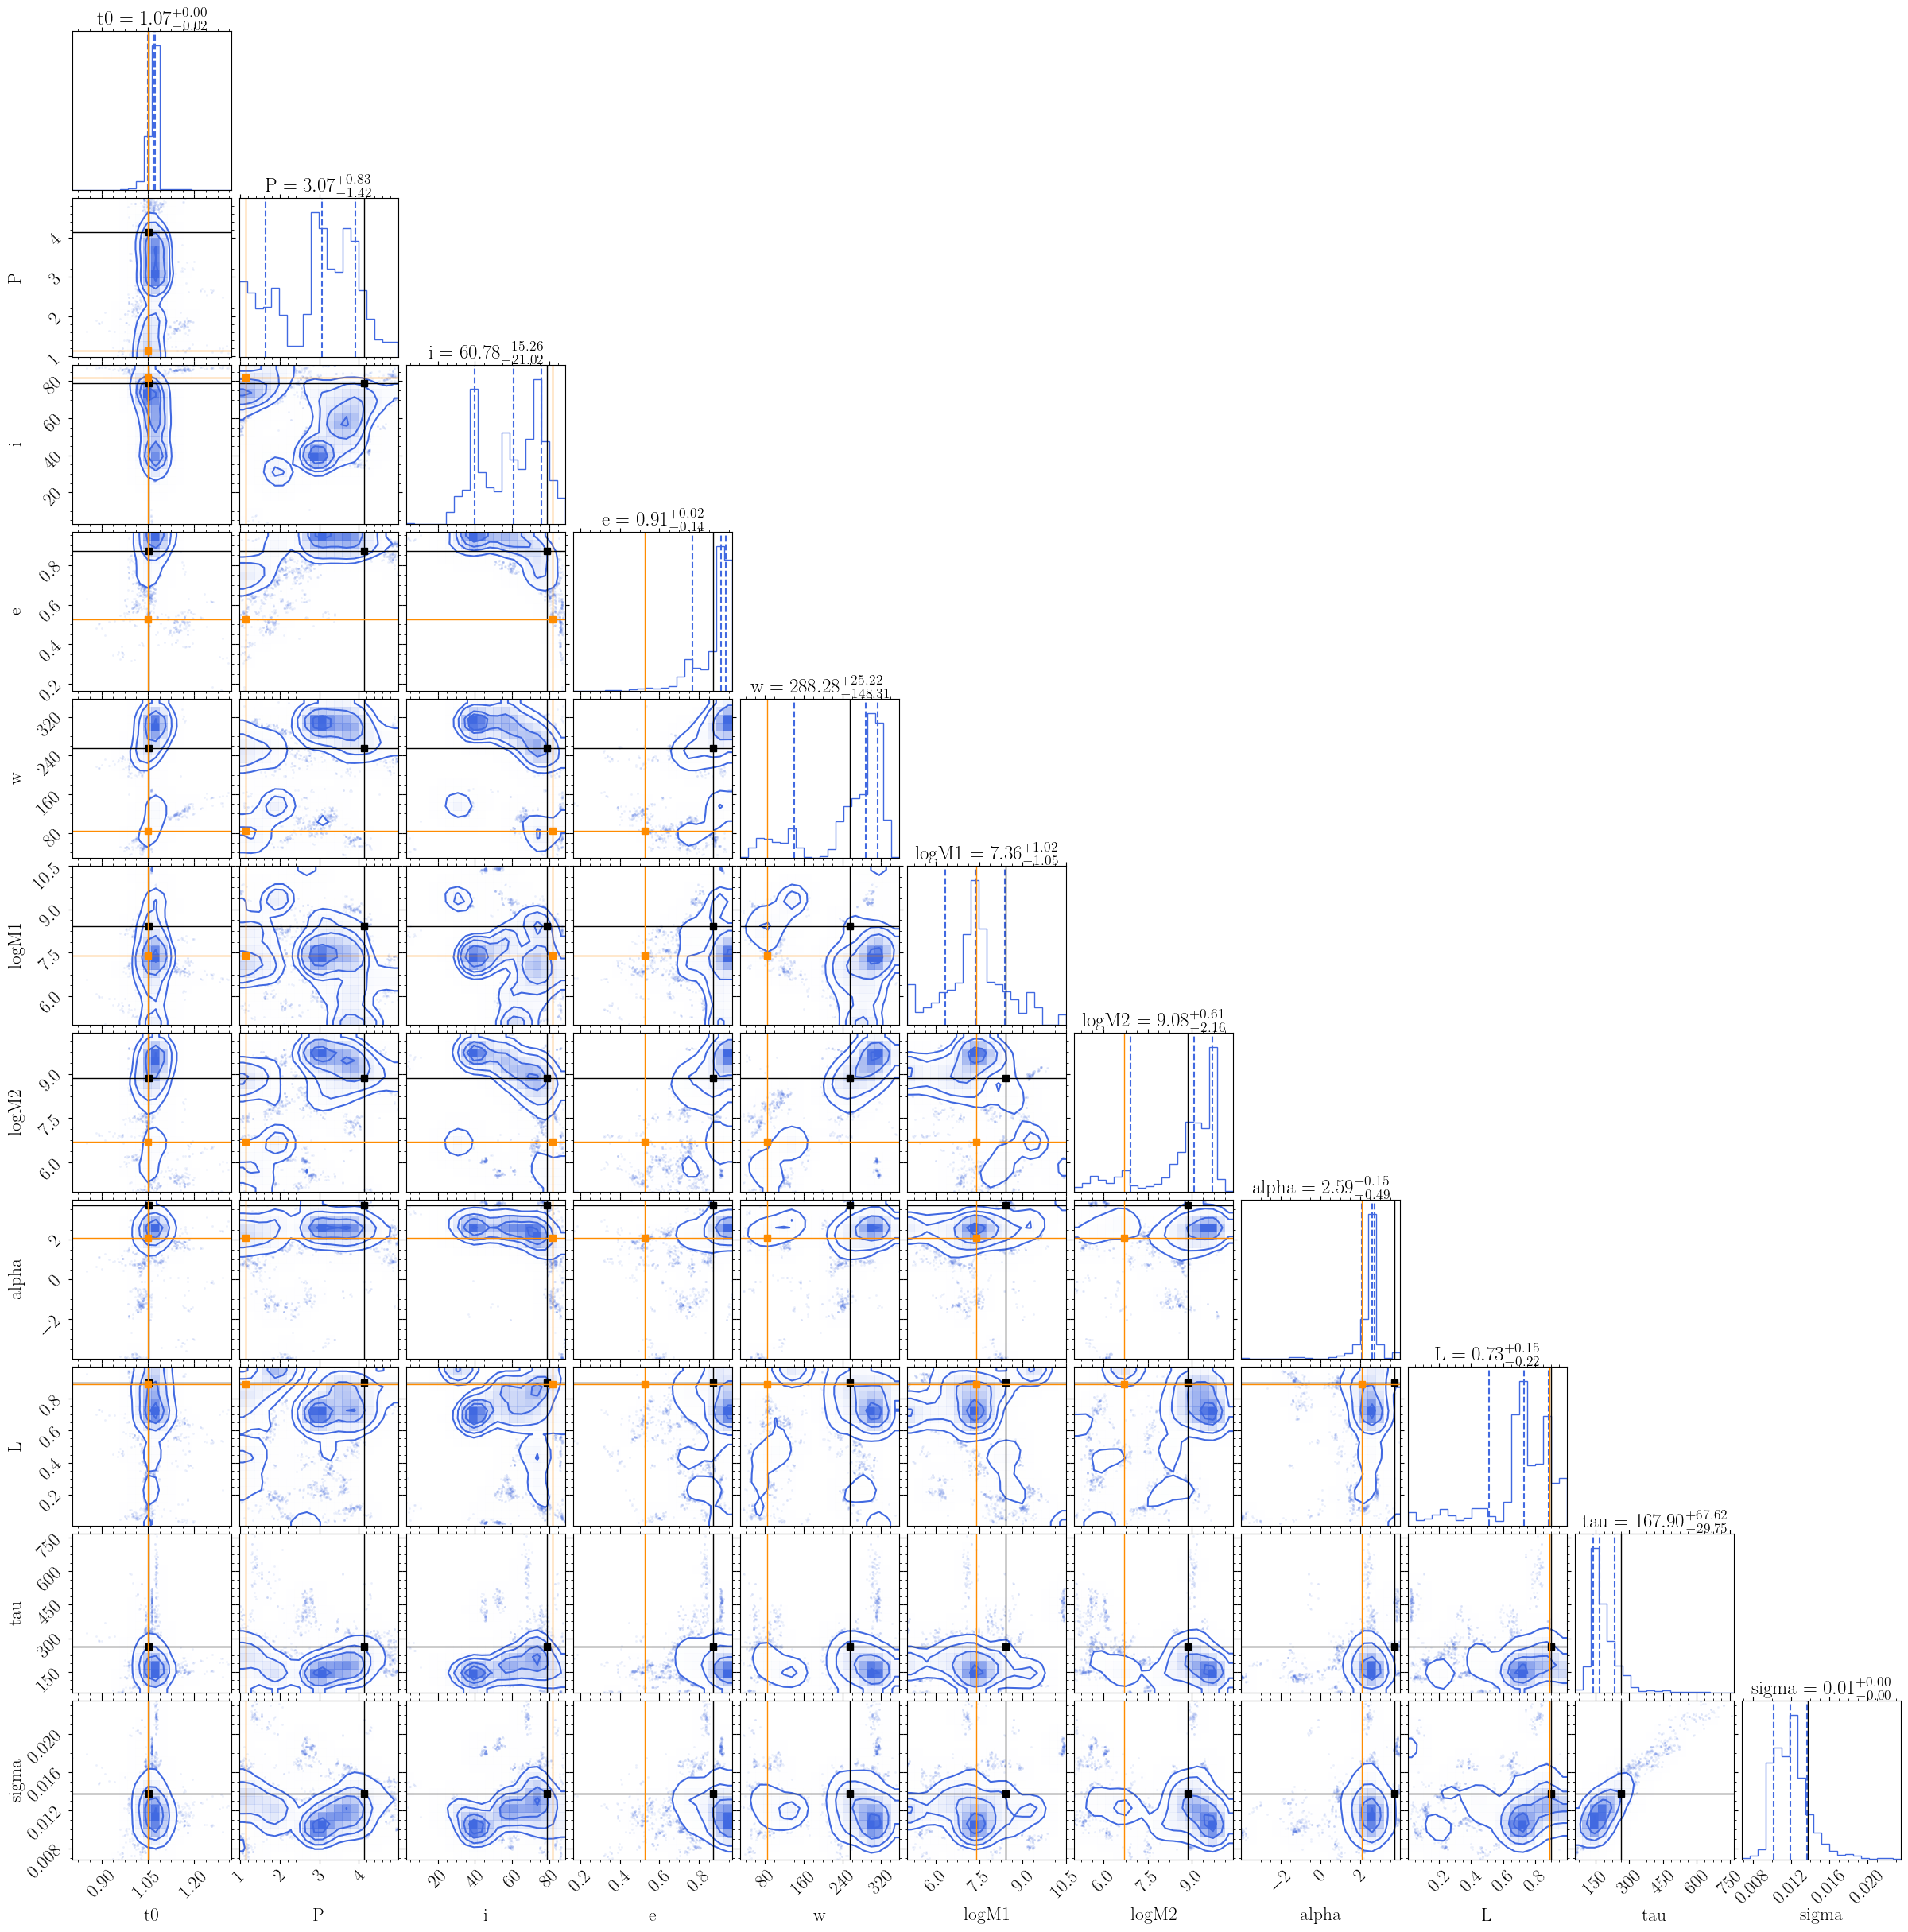

In [34]:
dm_QDM = bs.model_lightcurve_drw(time, result)
dm_DM = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm_QDM, Q0=Q0)
ax[0].plot(dm_DM.time, dm_DM.flux, c=cm, lw=1.5)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

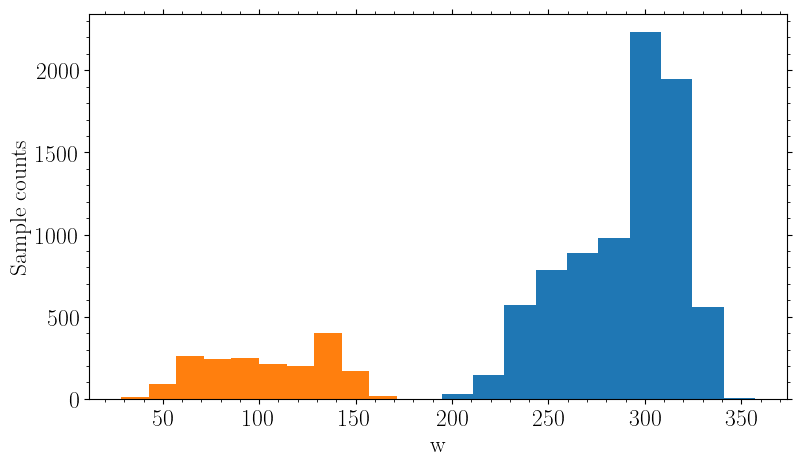

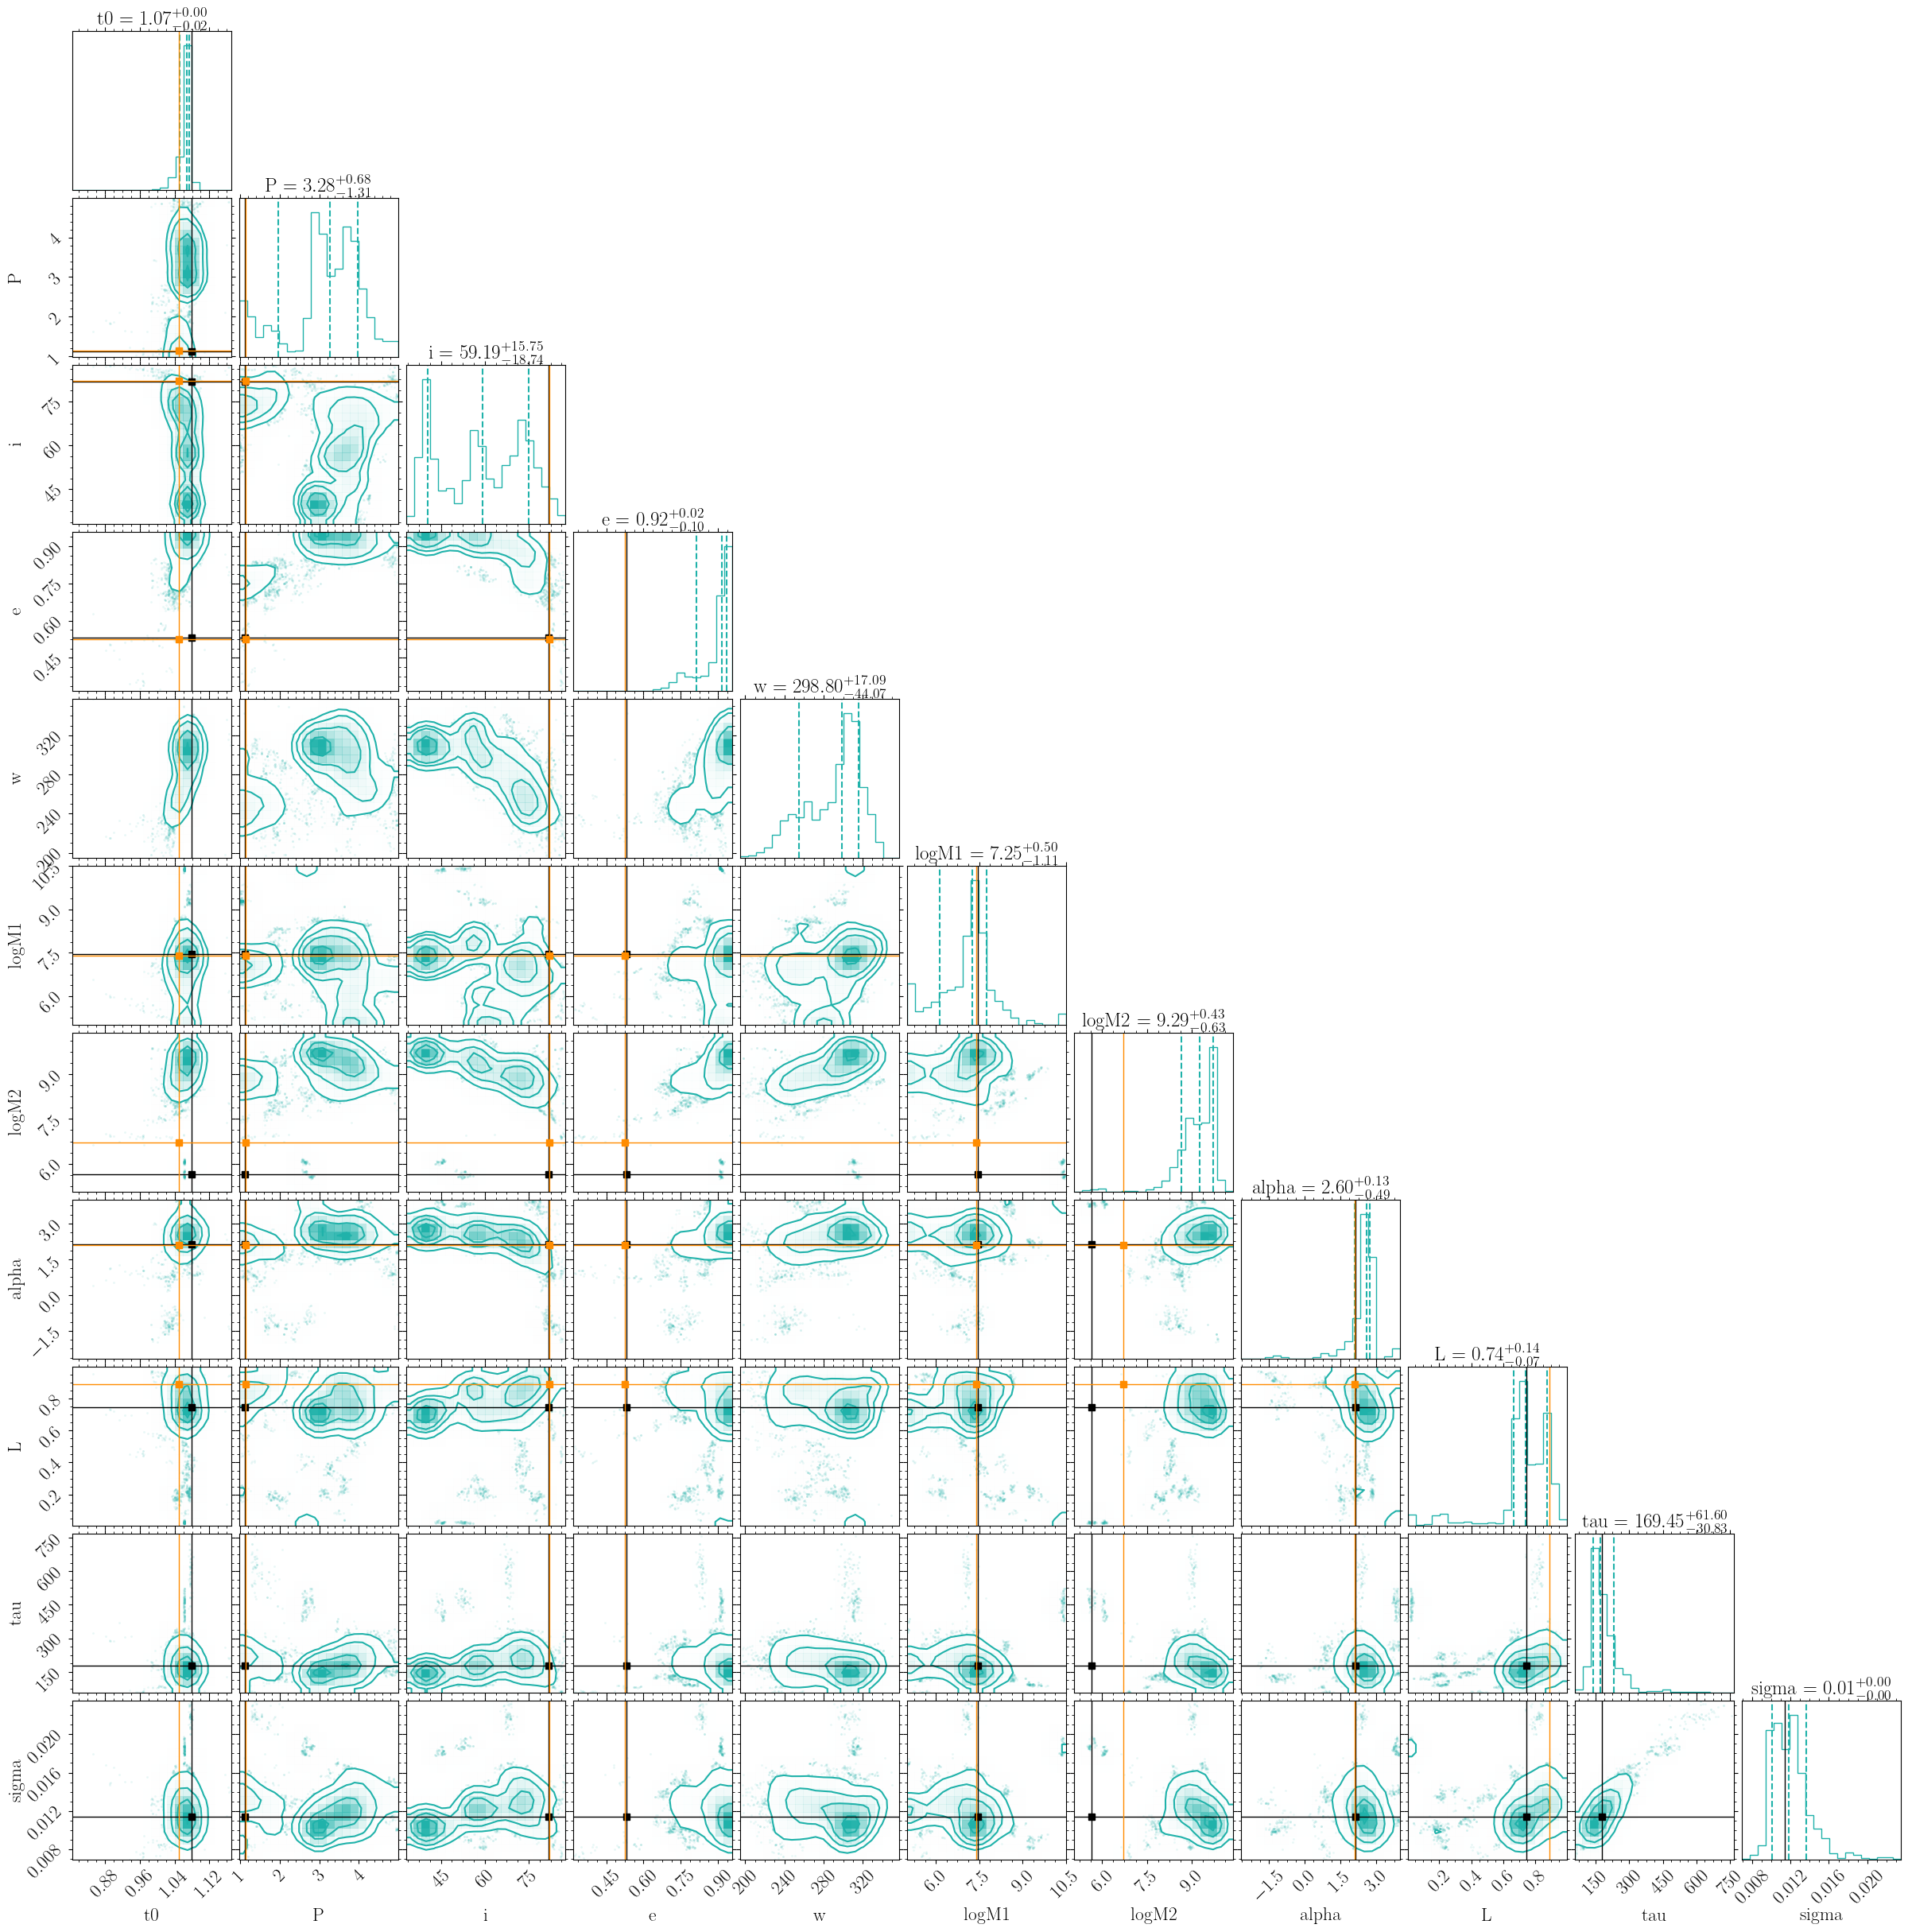

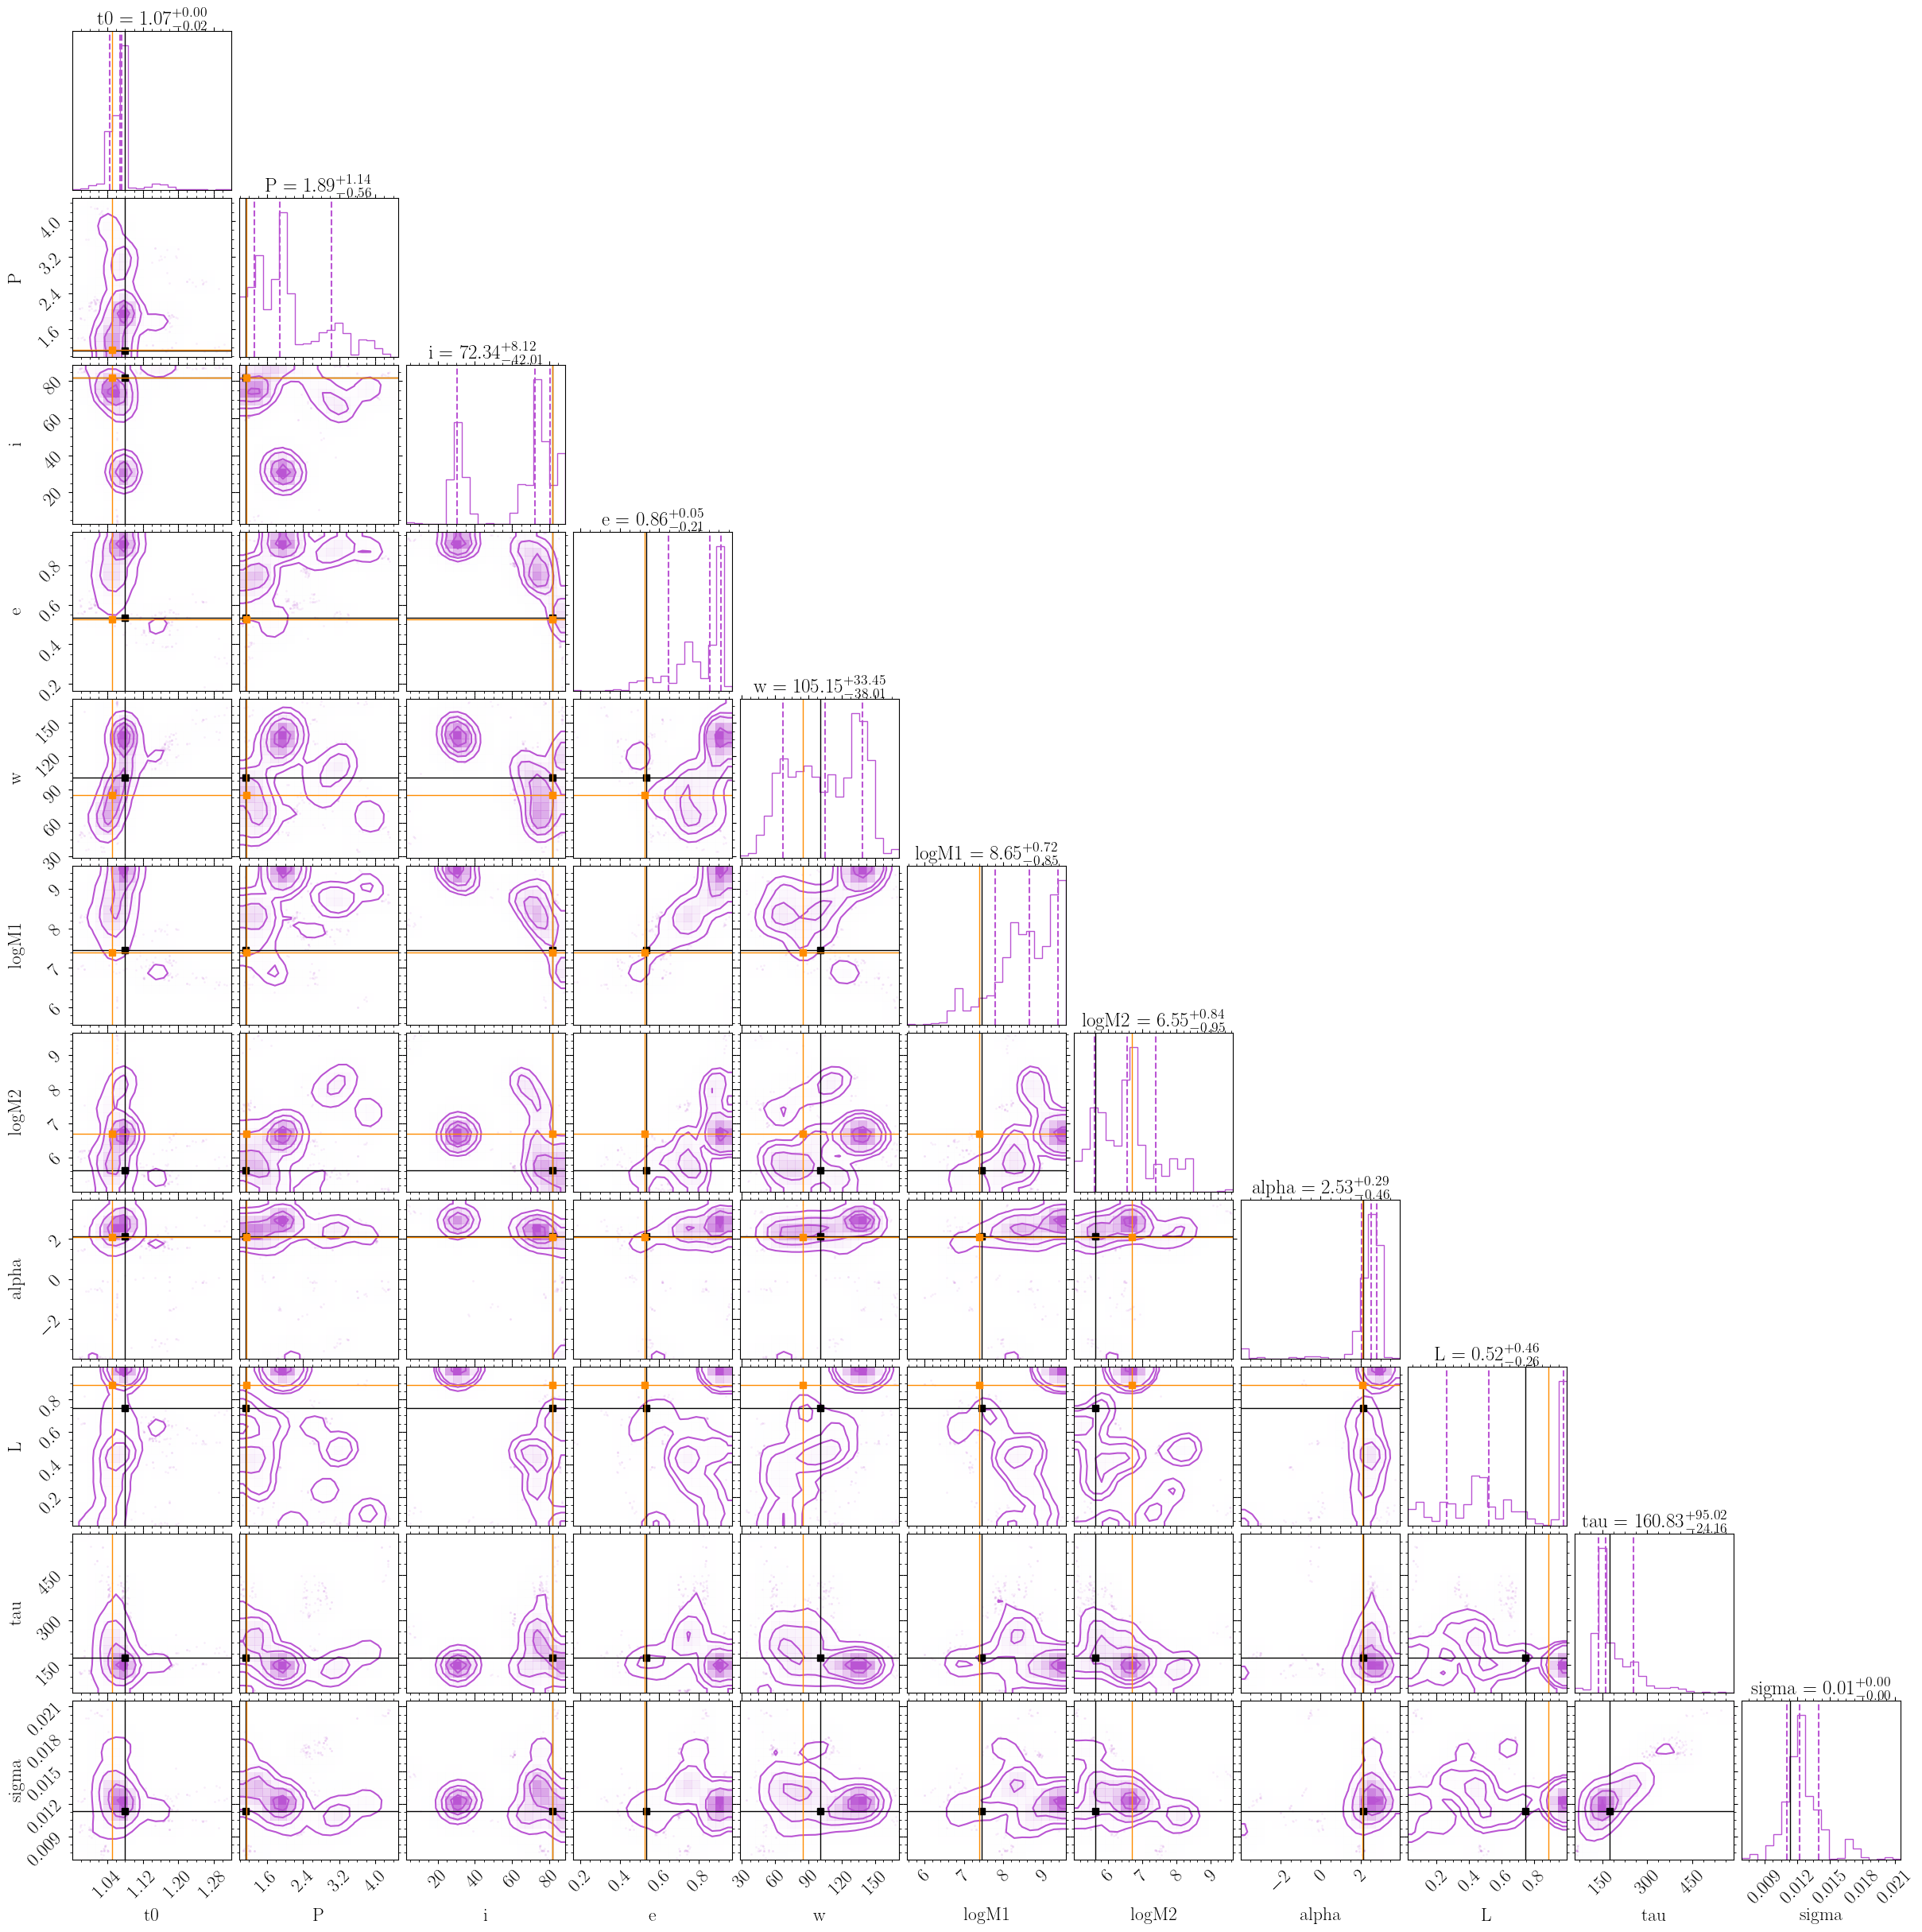

In [31]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1]
fig0 = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig1 = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

In [36]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

t0 : pmx { 1.06898 }{ -0.01646 }{ 0.00434 }
P : pmx { 3.27904 }{ -1.31247 }{ 0.68346 }
i : pmx { 59.18752 }{ -18.74110 }{ 15.75195 }
e : pmx { 0.91703 }{ -0.10231 }{ 0.01873 }
w : pmx { 298.79671 }{ -44.06876 }{ 17.08723 }
logM1 : pmx { 7.24914 }{ -1.11465 }{ 0.50195 }
logM2 : pmx { 9.28697 }{ -0.63250 }{ 0.43496 }
alpha : pmx { 2.59526 }{ -0.48954 }{ 0.12636 }
L : pmx { 0.73817 }{ -0.07069 }{ 0.13725 }
tau : pmx { 169.44824 }{ -30.82878 }{ 61.60086 }
sigma : pmx { 0.01176 }{ -0.00168 }{ 0.00184 }
